<a href="https://colab.research.google.com/github/Ashonet/Warframe_Trading_Analysis/blob/main/Trading_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_246/3965223672.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[BUY]        2020-11-20  728sh @ $13.05  ATR=$0.60  trail≈13.8%
[SELL]       2020-11-23  728sh @ $13.10  P&L=$+37.92
[BUY]        2020-12-14  718sh @ $13.27  ATR=$0.31  trail≈8.0%
[SELL]       2020-12-16  718sh @ $13.20  P&L=$-47.43
[BUY]        2021-01-21  686sh @ $13.83  ATR=$0.49  trail≈10.6%
[TRAIL STOP] 2021-02-25  686sh @ $13.27  peak=$15.29  trail=12.0%  stop=$13.46  P&L=$-383.06
[BUY]        2021-04-08  639sh @ $14.28  ATR=$0.41  trail≈8.7%
[TRAIL STOP] 2021-05-04  639sh @ $14.32  peak=$16.10  trail=9.1%  stop=$14.63  P&L=$+21.83
[BUY]        2021-06-02  546sh @ $16.74  ATR=$0.53  trail≈9.4%
[TRAIL STOP] 2021-07-15  546sh @ $18.92  peak=$20.65  trail=8.0%  stop=$19.00  P&L=$+1194.01
[BUY]        2021-08-05  499sh @ $20.59  ATR=$0.68  trail≈9.9%
[TRAIL STOP] 2021-09-28  499sh @ $20.66  peak=$22.79  trail=8.5%  stop=$20.85  P&L=$+32.68
[BUY]        2021-10-25  446sh @ $23.12  ATR=$0.53  trail≈8.0%
[SELL]       2021-12-17  446sh @ $27.75  P&L=$+2064.36
[BUY]        2022-03-24  436

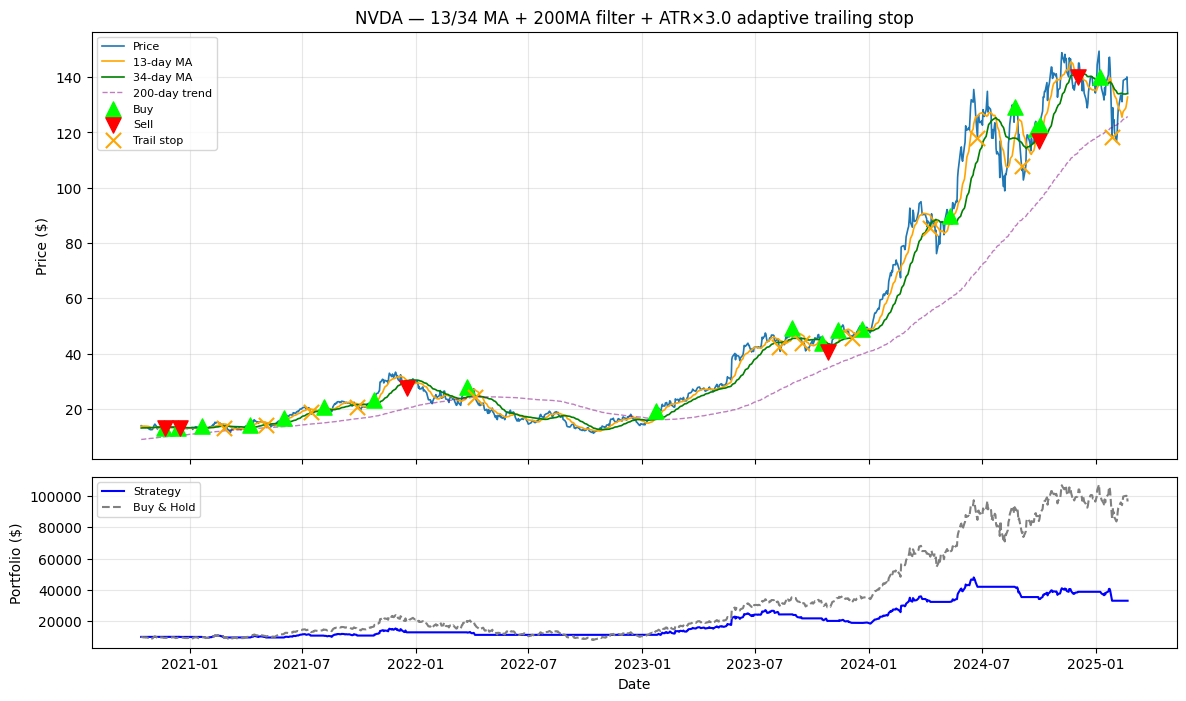

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parameters ────────────────────────────────────────────────────────────────
SYMBOL       = "NVDA"
START        = "2020-01-01"
END          = "2025-02-22"
INITIAL_CASH = 10_000.0

SHORT_WIN    = 13
LONG_WIN     = 34
TREND_WIN    = 200

ATR_WIN      = 14
ATR_MULT     = 3.0   # trailing stop = ATR_MULT × ATR below the peak
TRAIL_FLOOR  = 0.08  # never trail tighter than 8% (absolute floor)
TRAIL_CAP    = 0.30  # never trail wider than 30% (prevent runaway stops)
CASH_DEPLOY  = 0.95  # deploy 95% of cash on each signal

# ── Data ──────────────────────────────────────────────────────────────────────
raw = yf.download(SYMBOL, start=START, end=END, auto_adjust=True)
df  = raw[['Close', 'High', 'Low']].copy()
df.columns = ['Close', 'High', 'Low']

# ── Indicators ────────────────────────────────────────────────────────────────
df['MA_short'] = df['Close'].rolling(SHORT_WIN).mean()
df['MA_long']  = df['Close'].rolling(LONG_WIN).mean()
df['MA_trend'] = df['Close'].rolling(TREND_WIN).mean()

tr = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['Close'].shift()).abs(),
    (df['Low']  - df['Close'].shift()).abs(),
], axis=1).max(axis=1)
df['ATR'] = tr.rolling(ATR_WIN).mean()

df.dropna(inplace=True)

# ── Signals ───────────────────────────────────────────────────────────────────
ps = df['MA_short'].shift(1)
pl = df['MA_long'].shift(1)

df['Signal'] = 0
df.loc[
    (ps < pl) & (df['MA_short'] > df['MA_long']) & (df['Close'] > df['MA_trend']),
    'Signal'
] = 1
df.loc[
    (ps > pl) & (df['MA_short'] < df['MA_long']),
    'Signal'
] = -1

# ── Backtest ──────────────────────────────────────────────────────────────────
cash       = INITIAL_CASH
shares     = 0
buy_price  = 0.0
peak_price = 0.0
trades     = []
portfolio  = []

for idx, row in df.iterrows():
    price  = float(row['Close'])
    atr    = float(row['ATR'])
    signal = row['Signal']

    # ── Adaptive trailing stop (only fires if also below short MA) ────────────
    if shares > 0:
        peak_price = max(peak_price, price)

        # Trail distance: ATR-proportional, clamped between floor and cap
        atr_pct   = (atr * ATR_MULT) / peak_price
        trail_pct = float(np.clip(atr_pct, TRAIL_FLOOR, TRAIL_CAP))
        stop_lvl  = peak_price * (1 - trail_pct)

        # Dual confirmation: price below stop AND below short MA
        below_stop = price < stop_lvl
        below_ma   = price < float(row['MA_short'])

        if below_stop and below_ma:
            pnl   = shares * (price - buy_price)
            cash += shares * price
            trades.append(dict(date=idx, type='TRAIL_STOP', price=price, pnl=pnl))
            print(f"[TRAIL STOP] {idx.date()}  {shares}sh @ ${price:.2f}  "
                  f"peak=${peak_price:.2f}  trail={trail_pct*100:.1f}%  "
                  f"stop=${stop_lvl:.2f}  P&L=${pnl:+.2f}")
            shares = 0; peak_price = 0.0

    # ── MA crossover sell ─────────────────────────────────────────────────────
    if shares > 0 and signal == -1:
        pnl   = shares * (price - buy_price)
        cash += shares * price
        trades.append(dict(date=idx, type='SELL', price=price, pnl=pnl))
        print(f"[SELL]       {idx.date()}  {shares}sh @ ${price:.2f}  P&L=${pnl:+.2f}")
        shares = 0; peak_price = 0.0

    # ── Buy: deploy 95% of cash ───────────────────────────────────────────────
    if shares == 0 and signal == 1 and cash >= price:
        shares    = int(cash * CASH_DEPLOY / price)
        if shares > 0:
            cash     -= shares * price
            buy_price = price; peak_price = price
            trades.append(dict(date=idx, type='BUY', price=price, pnl=None))
            print(f"[BUY]        {idx.date()}  {shares}sh @ ${price:.2f}  "
                  f"ATR=${atr:.2f}  trail≈{np.clip((atr*ATR_MULT)/price, TRAIL_FLOOR, TRAIL_CAP)*100:.1f}%")

    portfolio.append(cash + shares * price)

# Close open position at end
if shares > 0:
    last_price = float(df['Close'].iloc[-1])
    pnl        = shares * (last_price - buy_price)
    cash      += shares * last_price
    trades.append(dict(date=df.index[-1], type='CLOSE', price=last_price, pnl=pnl))
    portfolio[-1] = cash

df['Portfolio'] = portfolio

# ── Results ───────────────────────────────────────────────────────────────────
tdf       = pd.DataFrame(trades)
final_val = df['Portfolio'].iloc[-1]
strat_ret = (final_val - INITIAL_CASH) / INITIAL_CASH * 100

bh_shares = int(INITIAL_CASH / float(df['Close'].iloc[0]))
bh_final  = bh_shares * float(df['Close'].iloc[-1])
bh_ret    = (bh_final - INITIAL_CASH) / INITIAL_CASH * 100

closed = tdf[tdf['pnl'].notna()]
wins   = closed[closed['pnl'] > 0]
losses = closed[closed['pnl'] <= 0]
stops  = tdf[tdf['type'] == 'TRAIL_STOP']

print(f"\n{'='*56}")
print(f"  {SYMBOL}  {SHORT_WIN}/{LONG_WIN} MA + ATR Trailing Stop")
print(f"{'='*56}")
print(f"  Final portfolio:   ${final_val:>10,.2f}")
print(f"  Strategy return:   {strat_ret:>+.1f}%")
print(f"  Buy-and-hold:      {bh_ret:>+.1f}%")
print(f"  Total trades:      {len(closed)}")
if len(closed):
    print(f"  Win rate:          {len(wins)/len(closed)*100:.1f}%")
    print(f"  Trailing stops:    {len(stops)}")
if len(wins):   print(f"  Avg win:           ${wins['pnl'].mean():>+,.2f}")
if len(losses): print(f"  Avg loss:          ${losses['pnl'].mean():>+,.2f}")
print(f"{'='*56}\n")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.2], hspace=0.06)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax1.plot(df.index, df['Close'],    label='Price',                  color='#1f77b4', lw=1.2)
ax1.plot(df.index, df['MA_short'], label=f'{SHORT_WIN}-day MA',    color='orange',  lw=1.2)
ax1.plot(df.index, df['MA_long'],  label=f'{LONG_WIN}-day MA',     color='green',   lw=1.2)
ax1.plot(df.index, df['MA_trend'], label=f'{TREND_WIN}-day trend', color='purple',  lw=1, ls='--', alpha=0.5)

if len(tdf):
    buys  = tdf[tdf['type'] == 'BUY']
    sells = tdf[tdf['type'].isin(['SELL', 'CLOSE'])]
    stops_df = tdf[tdf['type'] == 'TRAIL_STOP']
    ax1.scatter(buys['date'],     buys['price'],     marker='^', color='lime',   s=120, zorder=5, label='Buy')
    ax1.scatter(sells['date'],    sells['price'],    marker='v', color='red',    s=120, zorder=5, label='Sell')
    ax1.scatter(stops_df['date'], stops_df['price'], marker='x', color='orange', s=120, zorder=5, label='Trail stop')

ax1.set_ylabel("Price ($)")
ax1.set_title(f"{SYMBOL} — {SHORT_WIN}/{LONG_WIN} MA + {TREND_WIN}MA filter + ATR×{ATR_MULT} adaptive trailing stop")
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)
plt.setp(ax1.get_xticklabels(), visible=False)

bh_curve = [bh_shares * float(p) for p in df['Close']]
ax2.plot(df.index, df['Portfolio'], label='Strategy',   color='blue')
ax2.plot(df.index, bh_curve,        label='Buy & Hold', color='gray', ls='--')
ax2.set_ylabel("Portfolio ($)")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("trading_bot_v3.png", dpi=150, bbox_inches='tight')
plt.show()

[*********************100%***********************]  29 of 29 completed


Stocks: 29  |  Backtest weeks: 217

Pre-computing indicator surfaces...
Running 1944 parameter combinations...

  50/1944  (5s elapsed, ~190s remaining)
  100/1944  (9s elapsed, ~170s remaining)
  150/1944  (13s elapsed, ~158s remaining)
  200/1944  (18s elapsed, ~158s remaining)
  250/1944  (22s elapsed, ~149s remaining)
  300/1944  (26s elapsed, ~141s remaining)
  350/1944  (31s elapsed, ~139s remaining)
  400/1944  (35s elapsed, ~134s remaining)
  450/1944  (39s elapsed, ~129s remaining)
  500/1944  (44s elapsed, ~126s remaining)
  550/1944  (48s elapsed, ~121s remaining)
  600/1944  (52s elapsed, ~116s remaining)
  650/1944  (56s elapsed, ~112s remaining)
  700/1944  (60s elapsed, ~108s remaining)
  750/1944  (65s elapsed, ~103s remaining)
  800/1944  (70s elapsed, ~100s remaining)
  850/1944  (74s elapsed, ~95s remaining)
  900/1944  (78s elapsed, ~90s remaining)
  950/1944  (82s elapsed, ~86s remaining)
  1000/1944  (86s elapsed, ~81s remaining)
  1050/1944  (90s elapsed, ~77s re

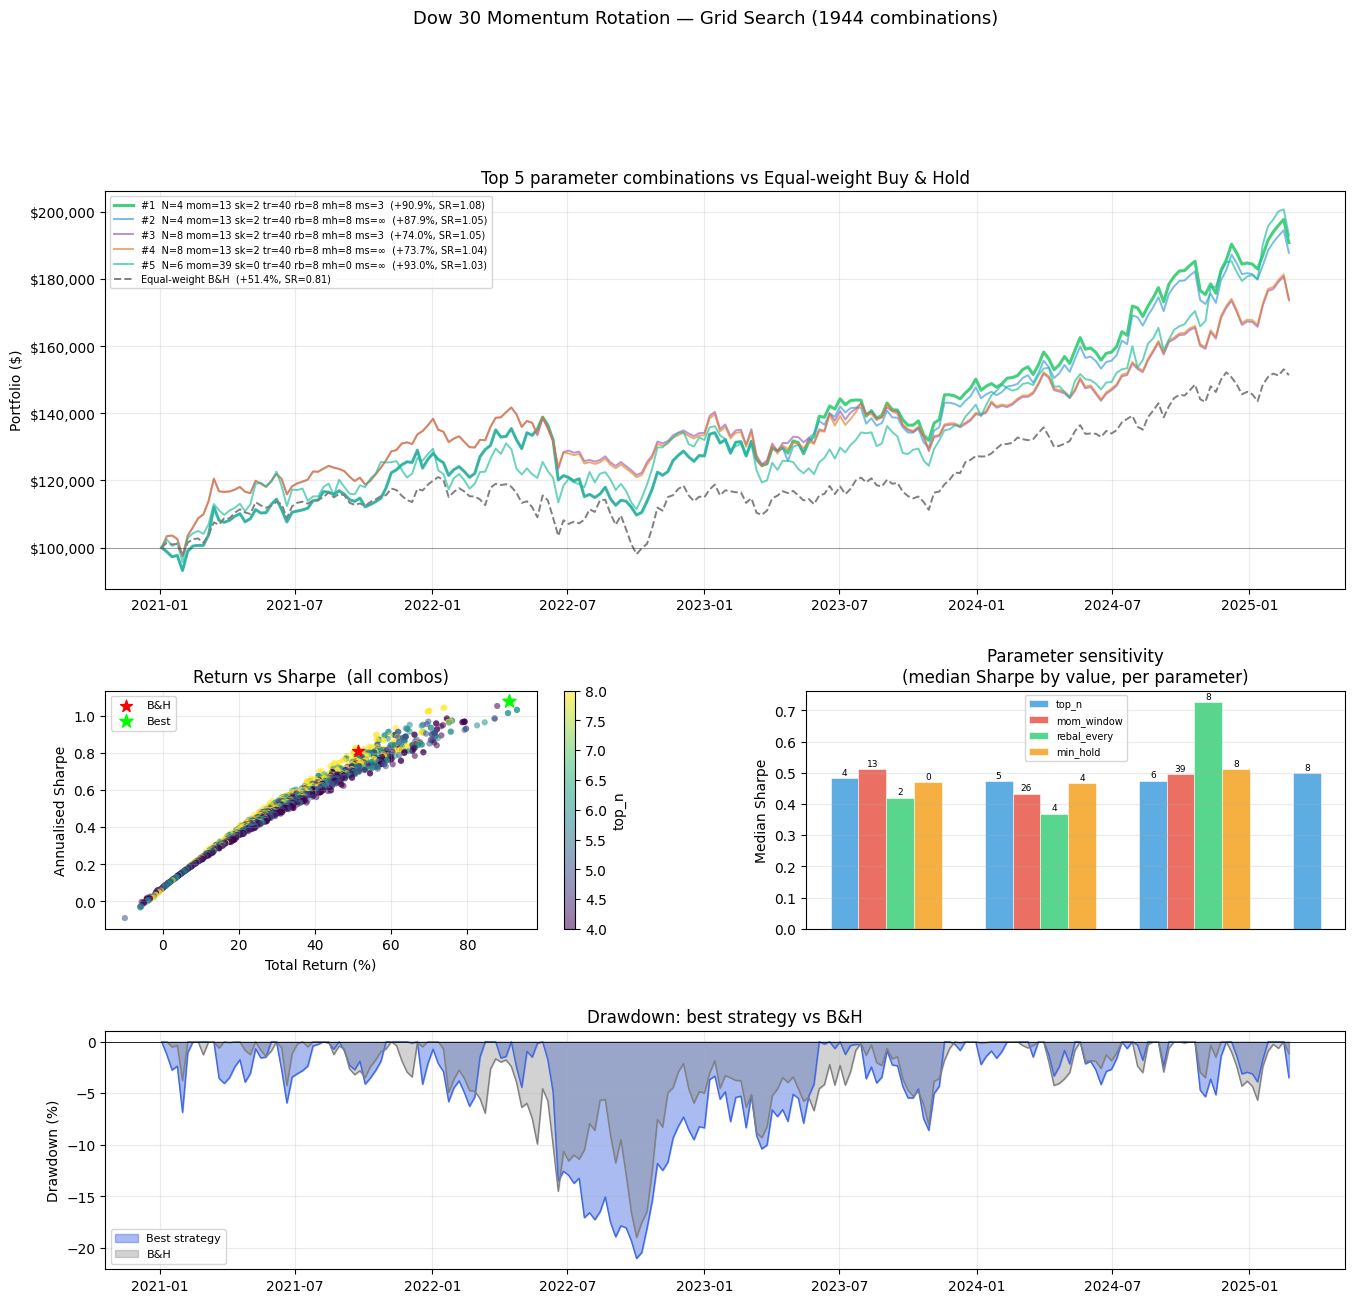

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from time import time

# ── Universe & data ───────────────────────────────────────────────────────────
DOW_30 = [
    "AAPL", "AMGN", "AXP", "BA", "CAT", "CSCO", "CVX", "DIS", "DOW",
    "GS", "HD", "HON", "IBM", "INTC", "JNJ", "JPM", "KO", "MCD", "MMM",
    "MRK", "MSFT", "NKE", "PFE", "PG", "TRV", "UNH", "V", "VZ", "WMT",
]

SECTORS = {
    "AAPL":"Tech",  "MSFT":"Tech",  "IBM":"Tech",   "INTC":"Tech",  "CSCO":"Tech",
    "V":"Fin",      "GS":"Fin",     "JPM":"Fin",    "AXP":"Fin",    "TRV":"Fin",
    "UNH":"Health", "JNJ":"Health", "MRK":"Health", "AMGN":"Health","PFE":"Health",
    "HD":"Cons",    "MCD":"Cons",   "NKE":"Cons",   "KO":"Cons",    "WMT":"Cons",
    "DIS":"Cons",   "PG":"Cons",
    "HON":"Ind",    "MMM":"Ind",    "CAT":"Ind",    "BA":"Ind",
    "CVX":"Energy", "DOW":"Matl",   "VZ":"Telecom",
}

START          = "2019-01-01"
END            = "2025-02-22"
BACKTEST_START = "2021-01-01"
INITIAL_CASH   = 100_000.0

print("Downloading data...")
raw = yf.download(DOW_30, start=START, end=END, auto_adjust=True, group_by="ticker")

def resample_weekly(t):
    try:
        return raw[t][['Close']].resample('W').last().dropna()
    except Exception:
        return None

weekly   = {t: resample_weekly(t) for t in DOW_30}
weekly   = {t: df for t, df in weekly.items() if df is not None and len(df) > 60}
all_cl   = pd.DataFrame({t: df['Close'] for t, df in weekly.items()})
all_cl   = all_cl.dropna(how='all').ffill()
wk_rets  = all_cl.pct_change()
bd       = all_cl[all_cl.index >= pd.Timestamp(BACKTEST_START)].index
print(f"Stocks: {len(weekly)}  |  Backtest weeks: {len(bd)}\n")

# ── Pre-cache momentum surfaces for all window combos ─────────────────────────
MOM_WINDOWS  = [13, 26, 39]
SKIP_OPTIONS = [0, 2, 4]
TREND_WINS   = [20, 40]

mom_cache   = {}
trend_cache = {}

print("Pre-computing indicator surfaces...")
for mw, sw in itertools.product(MOM_WINDOWS, SKIP_OPTIONS):
    if sw >= mw:
        continue
    key = (mw, sw)
    if sw > 0:
        mom_cache[key] = all_cl.pct_change(mw) - all_cl.pct_change(sw)
    else:
        mom_cache[key] = all_cl.pct_change(mw)

for tw in TREND_WINS:
    trend_cache[tw] = all_cl > all_cl.rolling(tw).mean()

# ── Fast backtest function ────────────────────────────────────────────────────
def run_backtest(top_n, mom_window, skip_weeks, trend_win, rebal_every, min_hold, max_sector):
    key = (mom_window, skip_weeks)
    if key not in mom_cache:
        return None

    mom_surf   = mom_cache[key]
    trend_surf = trend_cache[trend_win]

    cash     = INITIAL_CASH
    holdings = {}
    port_ts  = []
    r_count  = 0

    for i, date in enumerate(bd):
        r_count += 1
        do_rebal = (r_count % rebal_every == 0) or (i == 0)

        if do_rebal:
            scores = mom_surf.loc[date].dropna()
            above  = trend_surf.loc[date].fillna(False)
            elig   = scores[(scores > 0) & above]

            target  = []
            sec_cnt = {}
            for tkr in elig.nlargest(top_n * 4).index:
                sec = SECTORS.get(tkr, "Other")
                if sec_cnt.get(sec, 0) >= max_sector:
                    continue
                target.append(tkr)
                sec_cnt[sec] = sec_cnt.get(sec, 0) + 1
                if len(target) == top_n:
                    break

            for tkr in [t for t in list(holdings) if t not in target]:
                if holdings[tkr]['weeks_held'] >= min_hold:
                    price = float(all_cl.loc[date, tkr])
                    cash += holdings[tkr]['shares'] * price
                    del holdings[tkr]

            held_val  = sum(p['shares'] * float(all_cl.loc[date, t])
                            for t, p in holdings.items() if t in all_cl.columns)
            total_val = cash + held_val
            slot      = total_val / top_n

            for tkr in target:
                if tkr not in holdings and tkr in all_cl.columns:
                    price = float(all_cl.loc[date, tkr])
                    sh    = int(slot / price)
                    cost  = sh * price
                    if sh > 0 and cash >= cost:
                        cash -= cost
                        holdings[tkr] = {'shares': sh, 'buy_price': price, 'weeks_held': 0}

        for p in holdings.values():
            p['weeks_held'] += 1

        val = cash + sum(p['shares'] * float(all_cl.loc[date, t])
                         for t, p in holdings.items() if t in all_cl.columns)
        port_ts.append(val)

    return port_ts

def compute_metrics(port_ts):
    s    = pd.Series(port_ts)
    rets = s.pct_change().dropna()
    total_ret = (s.iloc[-1] / INITIAL_CASH - 1) * 100
    sharpe    = (rets.mean() / rets.std() * np.sqrt(52)) if rets.std() > 0 else 0
    roll_max  = s.cummax()
    drawdown  = ((s - roll_max) / roll_max).min() * 100
    return total_ret, sharpe, drawdown

# ── Parameter grid ────────────────────────────────────────────────────────────
GRID = {
    "top_n":       [4, 5, 6, 8],
    "mom_window":  [13, 26, 39],
    "skip_weeks":  [0, 2, 4],
    "trend_win":   [20, 40],
    "rebal_every": [2, 4, 8],
    "min_hold":    [0, 4, 8],
    "max_sector":  [2, 3, 99],
}

keys   = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
combos = [c for c in combos if c[2] < c[1]]

print(f"Running {len(combos)} parameter combinations...\n")

results = []
t0      = time()

for idx, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    if (idx + 1) % 50 == 0:
        elapsed = time() - t0
        eta     = elapsed / (idx + 1) * (len(combos) - idx - 1)
        print(f"  {idx+1}/{len(combos)}  ({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)")

    port_ts = run_backtest(**params)
    if port_ts is None:
        continue

    ret, sharpe, dd = compute_metrics(port_ts)
    # ── FIX: store orig_idx so sorting doesn't lose the pointer into results[] ──
    results.append({**params, 'return': ret, 'sharpe': sharpe, 'max_dd': dd,
                    'port_ts': port_ts, 'orig_idx': len(results)})

elapsed = time() - t0
print(f"\nDone in {elapsed:.1f}s  ({elapsed/len(combos)*1000:.0f}ms/combo)\n")

# ── Results table ─────────────────────────────────────────────────────────────
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'port_ts'} for r in results])
res_df = res_df.sort_values('sharpe', ascending=False).reset_index(drop=True)

# Equal-weight B&H benchmark
bh_start = bd[0]
bh_ts    = []
bh_init  = {}
for tkr in weekly:
    past = all_cl.loc[all_cl.index >= bh_start, tkr].dropna()
    if past.empty: continue
    sh = int((INITIAL_CASH / len(weekly)) / float(past.iloc[0]))
    bh_init[tkr] = (sh, float(past.iloc[0]))

for d in bd:
    val = INITIAL_CASH
    for tkr, (sh, entry) in bh_init.items():
        val += sh * (float(all_cl.loc[d, tkr]) - entry)
    bh_ts.append(val)

bh_ret, bh_sharpe, bh_dd = compute_metrics(bh_ts)

print(f"{'='*76}")
print(f"  TOP 15 CONFIGURATIONS  (ranked by Sharpe ratio)")
print(f"{'='*76}")
print(f"  {'Rank':>4}  {'N':>2}  {'Mom':>3}  {'Sk':>2}  {'Tr':>3}  {'Rb':>2}  "
      f"{'MH':>2}  {'MaxS':>4}  {'Return':>8}  {'Sharpe':>7}  {'MaxDD':>7}")
print(f"  {'-'*72}")
for i, row in res_df.head(15).iterrows():
    ms = "∞" if row['max_sector'] >= 99 else str(int(row['max_sector']))
    print(f"  {i+1:>4}  {int(row['top_n']):>2}  {int(row['mom_window']):>3}  "
          f"{int(row['skip_weeks']):>2}  {int(row['trend_win']):>3}  "
          f"{int(row['rebal_every']):>2}  {int(row['min_hold']):>2}  {ms:>4}  "
          f"{row['return']:>+7.1f}%  {row['sharpe']:>7.3f}  {row['max_dd']:>+7.1f}%")
print(f"  {'-'*72}")
print(f"  {'B&H':>30}  {bh_ret:>+7.1f}%  {bh_sharpe:>7.3f}  {bh_dd:>+7.1f}%")
print(f"{'='*76}")
print(f"\n  Column guide: N=positions  Mom=momentum window  Sk=skip weeks")
print(f"  Tr=trend MA  Rb=rebal frequency  MH=min hold  MaxS=max/sector\n")

# ── Parameter sensitivity ─────────────────────────────────────────────────────
print("\nParameter sensitivity (median Sharpe by value):")
for col in ['top_n', 'mom_window', 'skip_weeks', 'trend_win', 'rebal_every', 'min_hold', 'max_sector']:
    grouped = res_df.groupby(col)['sharpe'].median().sort_index()
    best    = grouped.idxmax()
    vals    = "  ".join(f"{v:.0f}→{s:.3f}" for v, s in grouped.items())
    print(f"  {col:15s}: {vals}  [best={best}]")

# ── Best strategy — use orig_idx to find correct entry in results[] ───────────
# FIX: res_df is sorted+reset, so res_df.iloc[0] is the best row.
#      orig_idx points back to the correct position in results[].
best = results[int(res_df.iloc[0]['orig_idx'])]
bp   = {k: best[k] for k in keys}

print(f"\n{'='*60}")
print(f"  BEST STRATEGY PARAMETERS")
print(f"{'='*60}")
for k, v in bp.items():
    print(f"  {k:15s}: {v}")
print(f"  return         : {best['return']:+.1f}%")
print(f"  sharpe         : {best['sharpe']:.3f}")
print(f"  max drawdown   : {best['max_dd']:+.1f}%")
print(f"{'='*60}\n")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, height_ratios=[2, 1.2, 1.2], hspace=0.35, wspace=0.3)

ax_main    = fig.add_subplot(gs[0, :])
ax_scatter = fig.add_subplot(gs[1, 0])
ax_sens    = fig.add_subplot(gs[1, 1])
ax_dd      = fig.add_subplot(gs[2, :])

# ── Equity curves: top 5 + B&H ───────────────────────────────────────────────
palette = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#1abc9c']
for rank, (_, row) in enumerate(res_df.head(5).iterrows()):
    # FIX: look up via orig_idx, not the sorted DataFrame index
    r   = results[int(row['orig_idx'])]
    ms  = "∞" if row['max_sector'] >= 99 else str(int(row['max_sector']))
    lbl = (f"#{rank+1}  N={int(row['top_n'])} mom={int(row['mom_window'])} "
           f"sk={int(row['skip_weeks'])} tr={int(row['trend_win'])} "
           f"rb={int(row['rebal_every'])} mh={int(row['min_hold'])} ms={ms}  "
           f"({row['return']:+.1f}%, SR={row['sharpe']:.2f})")
    ax_main.plot(bd, r['port_ts'], label=lbl, color=palette[rank],
                 lw=2.2 if rank == 0 else 1.4, alpha=0.9 if rank == 0 else 0.65)

ax_main.plot(bd, bh_ts, label=f"Equal-weight B&H  ({bh_ret:+.1f}%, SR={bh_sharpe:.2f})",
             color='gray', ls='--', lw=1.4)
ax_main.axhline(INITIAL_CASH, color='black', lw=0.6, alpha=0.4)
ax_main.set_ylabel("Portfolio ($)")
ax_main.set_title("Top 5 parameter combinations vs Equal-weight Buy & Hold", fontsize=12)
ax_main.legend(fontsize=7, loc='upper left')
ax_main.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax_main.grid(alpha=0.25)

# ── Scatter: return vs Sharpe ─────────────────────────────────────────────────
sc = ax_scatter.scatter(res_df['return'], res_df['sharpe'],
                        c=res_df['top_n'], cmap='viridis',
                        alpha=0.55, s=20, edgecolors='none')
ax_scatter.scatter(bh_ret, bh_sharpe, color='red',  s=80, zorder=5, marker='*', label='B&H')
ax_scatter.scatter(res_df.iloc[0]['return'], res_df.iloc[0]['sharpe'],
                   color='lime', s=100, zorder=6, marker='*', label='Best')
plt.colorbar(sc, ax=ax_scatter, label='top_n')
ax_scatter.set_xlabel("Total Return (%)")
ax_scatter.set_ylabel("Annualised Sharpe")
ax_scatter.set_title("Return vs Sharpe  (all combos)")
ax_scatter.legend(fontsize=8)
ax_scatter.grid(alpha=0.25)

# ── Sensitivity bars ──────────────────────────────────────────────────────────
sens_params = ['top_n', 'mom_window', 'rebal_every', 'min_hold']
n_bars  = len(sens_params)
bar_w   = 0.18
offsets = np.linspace(-(n_bars-1)/2 * bar_w, (n_bars-1)/2 * bar_w, n_bars)
colors2 = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for j, (col, color) in enumerate(zip(sens_params, colors2)):
    grp  = res_df.groupby(col)['sharpe'].median()
    xs   = np.arange(len(grp))
    bars = ax_sens.bar(xs + offsets[j], grp.values, bar_w,
                       label=col, color=color, alpha=0.8, edgecolor='white', lw=0.5)
    for bar, val in zip(bars, grp.index):
        ax_sens.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     str(int(val)), ha='center', va='bottom', fontsize=6.5)

ax_sens.set_ylabel("Median Sharpe")
ax_sens.set_title("Parameter sensitivity\n(median Sharpe by value, per parameter)")
ax_sens.legend(fontsize=7)
ax_sens.set_xticks([])
ax_sens.grid(axis='y', alpha=0.25)

# ── Drawdown: best strategy vs B&H ───────────────────────────────────────────
# FIX: use best['port_ts'] which is now correctly the #1 ranked strategy
best_s  = pd.Series(best['port_ts'])
bh_s    = pd.Series(bh_ts)
best_dd = (best_s - best_s.cummax()) / best_s.cummax() * 100
bh_dd_s = (bh_s   - bh_s.cummax())   / bh_s.cummax()   * 100

ax_dd.fill_between(bd, best_dd, alpha=0.45, color='royalblue', label='Best strategy')
ax_dd.fill_between(bd, bh_dd_s, alpha=0.35, color='gray',      label='B&H')
ax_dd.plot(bd, best_dd, color='royalblue', lw=1)
ax_dd.plot(bd, bh_dd_s, color='gray',      lw=1)
ax_dd.axhline(0, color='black', lw=0.6)
ax_dd.set_ylabel("Drawdown (%)")
ax_dd.set_title("Drawdown: best strategy vs B&H")
ax_dd.legend(fontsize=8)
ax_dd.grid(alpha=0.25)

plt.suptitle(f"Dow 30 Momentum Rotation — Grid Search ({len(combos)} combinations)",
             fontsize=13, y=1.01)
plt.savefig("dow30_grid_search.png", dpi=150, bbox_inches='tight')
plt.show()